# Práctica 3 - FdInder (Fecha de Entrega: 17 de Mayo / Entrega Temprana: 10 de Mayo)

Os doy la opción de hacer una entrega temprana el 10 de mayo si queréis tener feedback sobre vuestra práctica **antes** del examen. De todos modos, no hay ninguna diferencia en la nota de entregar en una fecha u otra.

Haced una **primera lectura** superficial para entender lo que se os pide, y luego id desarrollando poco a poco la aplicación. Acostumbraos a ir probando vuestro código de forma continua, de manera que podáis delimitar los posibles problemas que vayan surgiendo. En la práctica, el testing (por ejemplo, _tests unitarios_) y la refactorización de código son claves para hacer que este tipo de proyectos sean escalables.

## Enunciado

A nuestros alumnos de la Facultad de Informática se le han quedado un poco anticuadas las aplicaciones tradicionales de citas. Como solución, han decidido implementar su propia app, **FdInder**, en la que se permitan hacer _matches poliamorosos_ entre varios participantes con chats grupales.

## Modelos de Datos

Una app de citas totalmente funcional involucra multitud de entidades e información, así que en nuestro caso nos vamos a restringir a un modelo de datos sencillo que permita implementar las funcionalidades básicas de la aplicación. Por ello, tenemos el siguiente modelo de datos

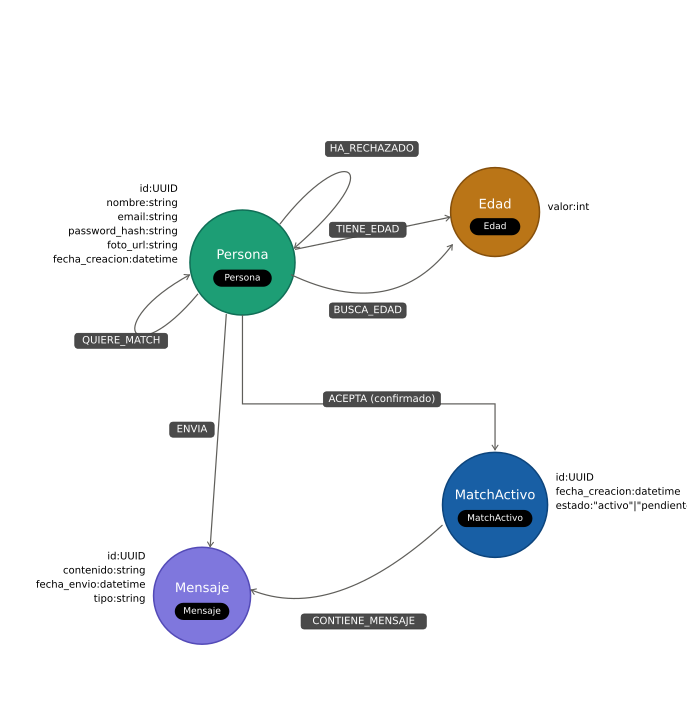

en que se involucran las siguientes componentes:

**Nodos**:

- `:Persona`, con las propiedades `id` (UUID), `nombre`, `email`, `password_hash`, `foto_url`, `fecha_creacion`. La base de datos se encuentra ya poblada con perfiles generados aleatoriamente con contraseña `pass1234`.
    
- `:MatchActivo`, con las propiedades `id` (UUID), `fecha_creacion`, `estado` (`"activo"` \| `"pendiente"`).

- `:Edad` con la propiedad `valor` (int).

- `:Mensaje`, con las propiedades `id` (UUID), `contenido`, `fecha_envio`, `tipo` (siempre tiene el valor `texto`, pero se incluye por si hubiese distintos tipos de mensajes).

**Relaciones**:

- `Persona -[:TIENE_EDAD]-> Edad`
- `Persona -[:BUSCA_EDAD]-> Edad`
- `Persona -[:QUIERE_MATCH]-> Persona`
- `Persona -[:HA_RECHAZADO]-> Persona`
- `Persona -[:ACEPTA]-> MatchActivo`, con la propiedad `confirmado` (booleano que indica si ha confirmado el match la persona o no, útil para matches poliamorosos).
- `Persona -[:ENVIA]-> Mensaje`
- `MatchActivo -[:CONTIENE_MENSAJE]-> Mensaje`

Los identificadores son identificadores de objetos únicos. Para ello, utilizaremos la librería `uuid` de `Python`, donde se puede generar un identificador único universal en formato `str` con la siguiente expresión:

```python
import uuid

new_id = str(uuid.uuid4())
```

### Lógica de match poliamoroso

Vamos a explicar cómo funciona un match poliamoroso entre varios usuarios, para evitar ambigüedades:

1. El usuario A hace swipe right sobre B (ruta `/aceptar`).

2. Se busca el camino más corto entre B y A con la relación `:QUIERE_MATCH`, para ver si el match es mutuo o hay posibilidad de un match poliamoroso:

   - **Sin camino**: se espera respuesta de B.

   - **Longitud 1**: eso quiere decir que B también ha hecho match. Este es un match directo, así que el match se genera automáticamente.

   - Existe al menos un camino **Longitud > 1**, y ninguno de longitud 1 (ciclo poliamoroso): se crea un match en estado pendiente que conecta a todos los participantes del ciclo, y se espera a que todos los usuarios acepten la petición del match poliamoroso.

4. Cada participante confirma en la ruta `/confirmar_match/<id>`:
   - Si todos confirman, entonces se formaliza el match.
   - Si alguno rechaza, se crean relaciones `HA_RECHAZADO` entre todos los participantes y se elimina el match.

Los mensajes solo existen en matches activos. Los matches pendientes nunca pueden tenerlos.

## Enrutado

Al igual que en la práctica anterior, el enrutado se encuentra descrito en el archivo `rutas.py`. Todas las rutas y sus métodos HTTP asociados están definidos, así que solo hay que seguir las indicaciones de los comentarios para implementar esos métodos. En los _templates_ se indica qué variables se deben suministrar y en qué formato.

## ¿Cómo abordar la práctica?

En esta práctica, a diferencia de la práctica anterior, todas las funcionalidades del sistema están conectadas con usuarios loggeados. Por tanto, el primer paso debe consistir en implementar las funcionalidades relacionadas con la autenticación: `/log_in`, `/sign_up` y `/log_out`. Para ello, utilizad la clase `Usuario` del módulo `modelos.py`, el cual tiene el método `from_node` para generar un objeto `Persona` a partir de un nodo `Persona`. Este método es un `@staticmethod`, así que se ejecuta directamente sobre una clase y no con una instancia concreta: `Persona.from_node()`.

Esta práctica es muy sencilla a nivel de qué funcionalidades se consideran. Hay dos grandes funcionalidades del sistema: los mecanismos para hacer match entre usuarios (rutas `/explorar`, `/aceptar/<id>` y `/rechazar/<id>`); y los mecanismos de gestión de matches en sí (`/matches`, `/match/<id>` y `/confirmar_match/<id>`). Ambos son independientes, así que se pueden implementar en cualquier orden. De hecho, la base de datos viene ya poblada con datos de _matches_ entre usuarios, así que la segunda funcionalidad se podría testear sin tener implementada la primera. Por simplicidad, las implementaremos en el orden en el que aparecen.

La funcionalidad de `/confirmar_match/` aparece en la ruta `/matches` cuando varios usuarios tienen un match poliamoroso. Para testearla, prueba a iniciar sesión con el usuario `sigfrido.arribas.105@fdinder.es` y accede a los matches para ver dos posibles matches poliamorosos. 

Para testear si se generan matches poliamorosos correctamente, haz login con el usuario `roberto.garay.6828@fdinder.es` y prueba en explorar a hacer match con `Ale Vallés` (debería ser de las primeras personas en aparecer cuando exploréis).

## ¿Por qué usar una Base de Datos Basada en Grafos?

Las bases de datos basadas en grafos no se suelen utilizar para el desarrollo de aplicaciones web. Una base de datos relacional suele cubrir todos los casos de usos en los que podríamos usar grafos, siendo los **DBMS** más robustos y optimizados. Sin embargo, en esta aplicación hay varias funcionalidades que serían muy complicadas de implementar haciendo uso de esta base de datos. Identificad qué funcionalidades se benefician de gestionar los datos en una base de datos basada en grafos, y qué ventajas tienen con respecto a implementarlas en el modelo relacional.

Escribid vuestra respuesta (un par de párrafos en `.txt` o **Word**) en un archivo `justificacion.txt` (o archivo **Word**).

## Entrega de la Práctica

Subid un archivo `*.zip` con el código que habéis modificado de `rutas.py`. Incluid un archivo `alumnos.txt` con el nombre y apellidos de los participantes de la práctica y el grupo, así como el archivo `justificacion.txt` con vuestro razonamiento del apartado anterior.